# YDFA modular model (uω-driven PSD)

This notebook rewrites the YDFA setup so all model variables live in a single parameter container `p`.

Key change vs `YDFA.ipynb`:
- the ODE state is `[Pp, Ps]` (pump power + total signal power),
- the spectral signal shape is provided by `p.uω`,
- the power spectral density is recomputed during every ODE evaluation from `p.uω`.

Because `p` is mutable, you can update `p.uω` during the solve (e.g., via callbacks).


In [134]:
using Interpolations
using Revise
using Printf
using LinearAlgebra
using PyPlot
using FFTW
using MultiModeNoise
using DifferentialEquations


In [135]:
# --- Physical constants ---
const h = 6.62607015e-34
const c = 2.99792458e8

# --- Simulation grid for signal spectrum ---
λ0 = 1030e-9
M = 1
Nt = 2^12
time_window = 10 # ps
β_order = 2
sim = MultiModeNoise.get_disp_sim_params(λ0, M, Nt, time_window, β_order)

# --- Seed field definition (this is p.uω, not an ODE state vector) ---
P_cont = 0.02 # W average
pulse_fwhm = 200e-15
pulse_rep_rate = 80e6
ut0, uω0 = MultiModeNoise.get_initial_state([1], P_cont, pulse_fwhm, pulse_rep_rate, "sech_sq", sim)


(ComplexF64[4.828286567677659e-18 + 0.0im; 4.9333042204189036e-18 + 0.0im; … ; 5.040606059741217e-18 + 0.0im; 4.9333042204189036e-18 + 0.0im;;], ComplexF64[1.1831412271166926 + 0.0im; -1.1757614087230202 + 1.4644017484990598e-18im; … ; 1.1540754795997725 - 3.0911482321365385e-17im; -1.1757614087230202 - 1.557962297366538e-17im;;])

In [136]:
# --- Single modular parameter container ---
Base.@kwdef mutable struct YDFAParams
    # Geometry / dopant
    L::Float64 = 2.5
    core_radius::Float64 = 2.5e-6
    NA::Float64 = 0.13
    A::Float64 = pi * core_radius^2
    rho::Float64 = 1e25
    tau21::Float64 = 1.4e-3

    # Pump channel
    λp::Float64 = 976e-9
    νp::Float64 = c / λp
    σap::Float64 = 2.5e-24
    σep::Float64 = 2.5e-24

    # Signal channel
    λs0::Float64 = 1030e-9
    νs0::Float64 = c / λs0

    # Signal channel grid
    fs::Vector{Float64}
    Δt::Float64
    Nt::Int
    νs::Vector{Float64} = fs .* 1e12
    dt::Float64 = Δt * 1e-12
    df::Float64 = 1 / (Nt * dt)
    pulse_rep_rate::Float64 = 80e6

    # Signal field in frequency domain (mutable, can be changed during solve)
    uω::Vector{ComplexF64} = ComplexF64.(uω0[:, 1])

     # Overlap factors
    V_p::Float64 = 2 * pi * core_radius * NA / (λp)  # Normalized Frequency
    w_p::Float64 = core_radius * (0.616 + 1.66/(V_p^1.5) + 0.987/(V_p^6))
    Gamma_p::Float64 = 1-exp(-2*core_radius^2 / w_p^2)          # Overlap factor

    V_s::Float64 = 2 * pi * core_radius * NA / (λs0)  # Normalized Frequency
    w_s::Float64 = core_radius * (0.616 + 1.66/(V_s^1.5) + 0.987/(V_s^6))
    Gamma_s::Float64 = 1-exp(-2*core_radius^2 / w_s^2)

    # Cross sections on fs grid (filled from gain.jl helper)
    σas::Vector{Float64} = zeros(length(fs))
    σes::Vector{Float64} = zeros(length(fs))
end

p = YDFAParams(fs=sim["fs"], Δt=sim["Δt"], Nt=sim["Nt"])

# Use gain.jl helper already in package
xs = MultiModeNoise.get_ydfa_cross_sections(p.fs)
p.σas .= xs["sigma_as"]
p.σes .= xs["sigma_es"]

@printf("Cross-sections loaded on %d frequency bins
", length(p.fs))


Cross-sections loaded on 4096 frequency bins


In [ ]:
# --- Modular helpers ---
function psd_from_uω(uω::AbstractMatrix{<:Complex}, p::YDFAParams)
    # Convert MultiModeNoise FFT convention to physical ESD/PSD
    uω_s = uω .* p.Nt .* p.dt
    ESD = abs2.(uω_s)
    return fftshift(ESD) .* p.pulse_rep_rate # W/Hz
end

function inversion(Pp::ComplexF64, Ps_vec::AbstractVector{<:Real}, p::YDFAParams)
    R12 = (p.Gamma_p * p.σap * Pp) / (h * p.νp * p.A)
    R21 = (p.Gamma_p * p.σep * Pp) / (h * p.νp * p.A)

    W12 = sum((p.Gamma_s .* p.σas .* Ps_vec .* p.df) ./ (h .* p.νs .* p.A))
    W21 = sum((p.Gamma_s .* p.σes .* Ps_vec .* p.df) ./ (h .* p.νs .* p.A))

    n2 = (R12 + W12) / (R12 + R21 + W12 + W21 + 1 / p.tau21)
    n1 = 1 - n2

    gν = p.Gamma_s .* (p.σes .* n2 .- p.σas .* n1) .* p.rho

    return n1, n2, gν
end

# function gain_spectrum(Pp::Float64, Ps_vec::AbstractVector{<:Real}, p::YDFAParams)
#     n1, n2 = inversion(Pp, Ps_vec, p)
#     return p.Gamma_s .* (p.σes .* n2 .- p.σas .* n1) .* p.rho
# end


inversion (generic function with 2 methods)

In [138]:
summary(uω0[:, 1])

"4096-element Vector{ComplexF64}"

In [139]:
# --- ODE with modular parameter p and uω-driven PSD ---
function ydfa_modular!(du, u, p::YDFAParams, z)
    Pp = u[1]         # Pump power [W]
    uω = u[2:end]
    Ps_vec = psd_from_uω(uω, p) # W/Hz on fs grid

    # Rebuild spectral signal distribution from current p.uω each call
    # Ps_vec = spectral_power_bins(Ps, p) # W/Hz on fs grid
    n1, n2, gν = inversion(Pp, Ps_vec, p)   # 1/m on fs grid

    # n1, n2 = inversion(Pp, Ps_vec, p)

    # Pump equation
    du[1] = p.Gamma_p * (p.σep * n2 - p.σap * n1) * p.rho * Pp

    # Total signal equation = integral over spectral channels
    @. du[2:end] = 0.5*gν * uω
end

# Initial ODE state: [pump power, total signal power]
Pp0 = 0.6
# Ps0_vec = psd_from_uω(uω0, p)
u0 = vcat(complex(Pp0, 0.0), uω0)

zsave = range(0, p.L, length=200)
prob = ODEProblem(ydfa_modular!, u0, (0.0, p.L), p)
sol = solve(prob, Tsit5(); saveat=zsave, reltol=1e-8, abstol=1e-8);


MethodError: MethodError: no method matching inversion(::ComplexF64, ::Vector{Float64}, ::YDFAParams)
The function `inversion` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  inversion(!Matched::Float64, ::AbstractVector{<:Real}, ::YDFAParams)
   @ Main c:\Users\fadif\Documents\Code\Work\MyGain\smf-gain-noise\test\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X30sZmlsZQ==.jl:9
  inversion(!Matched::Float64, !Matched::AbstractMatrix{<:Real}, ::YDFAParams)
   @ Main c:\Users\fadif\Documents\Code\Work\MyGain\smf-gain-noise\test\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X30sZmlsZQ==.jl:9


200-element Vector{Float64}
4096×200 Matrix{Float64}


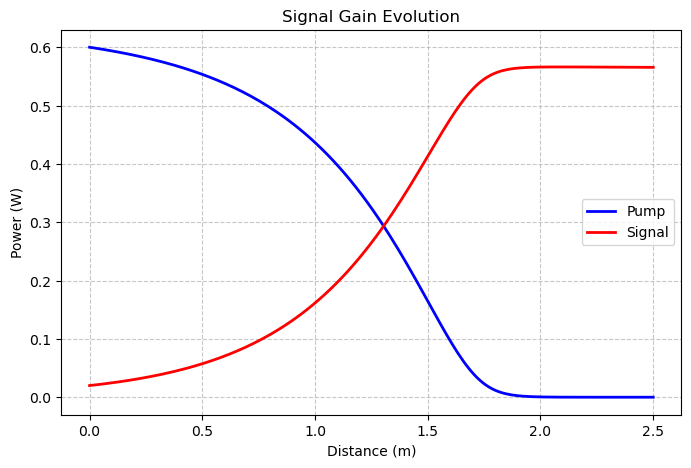

In [140]:
z    = sol.t          # Fiber positions
Pp_z = sol[1, :]      # Pump power along z
Ps_fz = sol[2:end, :]; # Signal spectrum matrix (Frequencies x Z-steps)
Ps_z = vec(sum(Ps_fz, dims=1)) .* p.df

println(summary(Pp_z))
println(summary(Ps_fz))

Ps_start = Ps_fz[:, 1]
Ps_end = Ps_fz[:, end]

# 3. Create the plot
fig = figure(figsize=(8, 5))

# Plot Signal and PUmp power over length
# plot(z_save, Ps_raw, label="Signal", color="red", linewidth=2)
plot(zsave, Pp_z, label="Pump", color="blue", linewidth=2)
plot(zsave, Ps_z, label="Signal", color="red", linewidth=2)

# 4. Formatting
title("Signal Gain Evolution")
xlabel("Distance (m)")
ylabel("Power (W)") # Changed from Power (W) to Gain (dB)
# ylim(-10, 40)
grid(true, linestyle="--", alpha=0.7)
legend()

fig

0.020000544619050317
0.5655080947949482


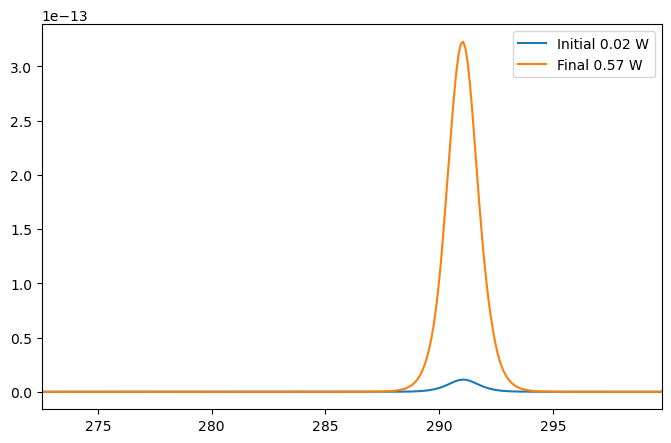

In [141]:
# 3. Create the plot
fig = figure(figsize=(8, 5))

println(sum(Ps_start) * p.df)
println(sum(Ps_end) * p.df)

# Plot Signal and PUmp power over length
# plot(z_save, Ps_raw, label="Signal", color="red", linewidth=2)
plot(sim["fs"], Ps_start, label="Initial $(round((sum(Ps_start) * p.df), digits=2)) W")
plot(sim["fs"], Ps_end, label="Final $(round((sum(Ps_end) * p.df), digits=2)) W")
xlim(c/1100 * 1e-12 * 1e9, c/1000 * 1e-12 * 1e9)
legend()
fig